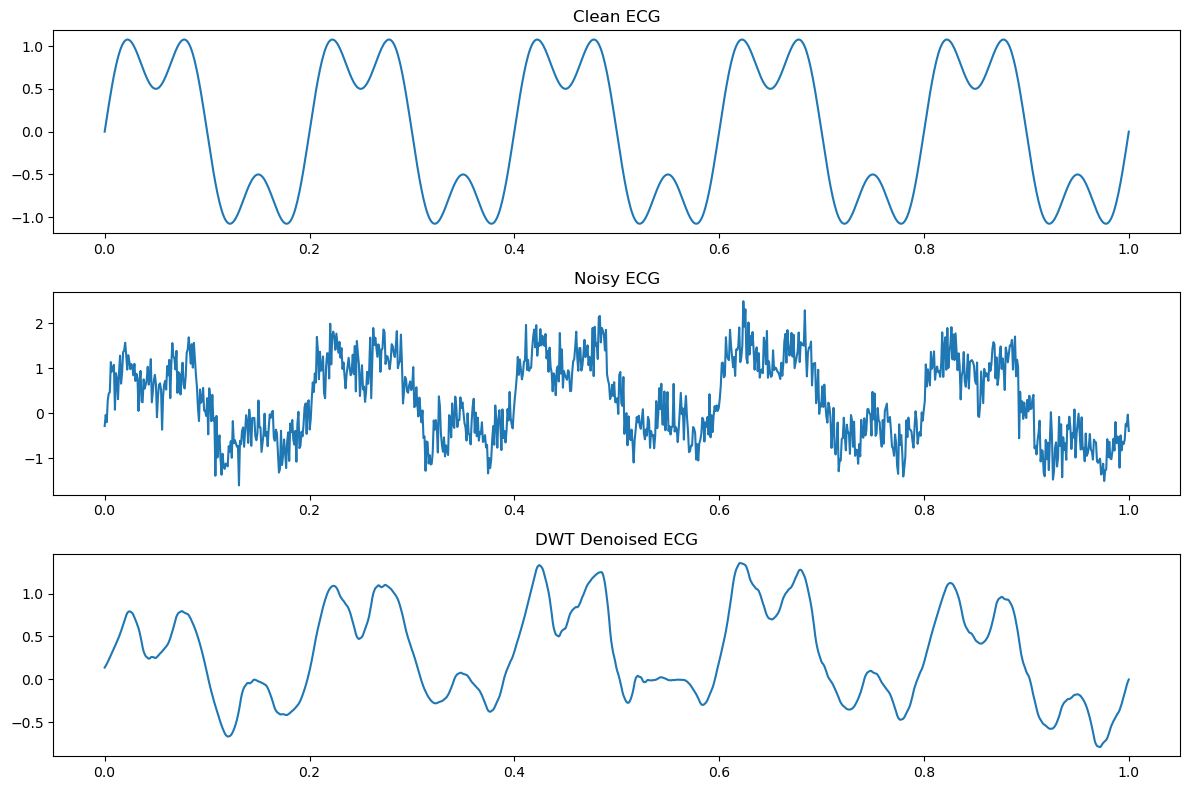

MSE: 0.18766207287325054
SNR: 5.220689964341998


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

fs = 1000
t = np.linspace(0, 1, fs)

ecg_clean = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 15 * t)

baseline_drift = 0.5 * np.sin(2 * np.pi * 0.5 * t)
powerline_noise = 0.2 * np.sin(2 * np.pi * 50 * t)
emg_noise = 0.3 * np.random.randn(len(t))

ecg_noisy = ecg_clean + baseline_drift + powerline_noise + emg_noise

def dwt_denoise(signal, wavelet='db4', level=4):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(signal)))
    new_coeffs = [pywt.threshold(c, threshold, mode='soft') for c in coeffs]
    return pywt.waverec(new_coeffs, wavelet)

ecg_denoised = dwt_denoise(ecg_noisy)

def mse(x, y):
    return np.mean((x - y) ** 2)

def snr(x, y):
    noise = x - y
    return 10 * np.log10(np.sum(x ** 2) / np.sum(noise ** 2))

mse_value = mse(ecg_clean, ecg_denoised)
snr_value = snr(ecg_clean, ecg_denoised)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, ecg_clean)
plt.title("Clean ECG")

plt.subplot(3, 1, 2)
plt.plot(t, ecg_noisy)
plt.title("Noisy ECG")

plt.subplot(3, 1, 3)
plt.plot(t, ecg_denoised)
plt.title("DWT Denoised ECG")

plt.tight_layout()
plt.show()

print("MSE:", mse_value)
print("SNR:", snr_value)